# Use Case: Tropical Nights and Cooling Demand Analysis

> [!NOTE]
> The data shown in this repository is for **demonstration purposes only**. To obtain the full datasets for professional analysis, please use the official channels.

This notebook explores how increasing temperatures affect nighttime heat stress and the demand for cooling. We use `earthkit-climate` to compute tropical nights and cooling degree days, analyzing their trends and correlation.

We'll use:
- **`tropical_nights`**: Number of days where $T_{min} > 20^{\circ}C$.
- **`cooling_degree_days`**: Cumulative degrees above a comfort threshold ($18^{\circ}C$).

The workflow includes loading temperature data, computing indices, performing trend analysis, and visualizing the relationship between the two indicators.

In [1]:
import warnings

import cartopy.crs as ccrs
import earthkit.data as ekd
import earthkit.plots as ekp
import matplotlib.pyplot as plt

from earthkit.climate.indicators.temperature import (
    cooling_degree_days,
    tropical_nights,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)

## Loading Data

We load historical daily minimum temperature (`tasmin`) from CMIP6 simulations. We will use `tasmin` also as a proxy for `tas` to calculate cooling degree days if `tas` is not available, or just focus on minimum temperature trends if preferred. Here we load `tasmin` to compute tropical nights.

In [5]:
tasmin_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmin_ACCESS-CM2_historical_reference.nc",
)
ds_tasmin = tasmin_hist.to_xarray()

## Computing Indices

We compute the indices on an annual basis. For demonstration, we'll use `tasmin` for both, noting that `cooling_degree_days` usually uses `tas`.

In [6]:
# Compute annual tropical nights
tn = tropical_nights(ds_tasmin.tasmin, thresh="293.15 K", freq="YS")

# Compute annual cooling degree days (using tasmin for this example)
cdd = cooling_degree_days(ds_tasmin.tasmin, thresh="291.15 K", freq="YS")

## Trend Analysis

We estimate the trend for both indicators over the available period.

In [7]:
# Simple linear trend using xarray's polyfit
tn_trend = tn.polyfit(dim='time', deg=1).polyfit_coefficients.sel(degree=1) * 1e9 * 60 * 60 * 24 * 365 * 10
cdd_trend = cdd.polyfit(dim='time', deg=1).polyfit_coefficients.sel(degree=1) * 1e9 * 60 * 60 * 24 * 365 * 10

## Visualization

### Trend Maps

We visualize the spatial patterns of trends in tropical nights and cooling degree days.

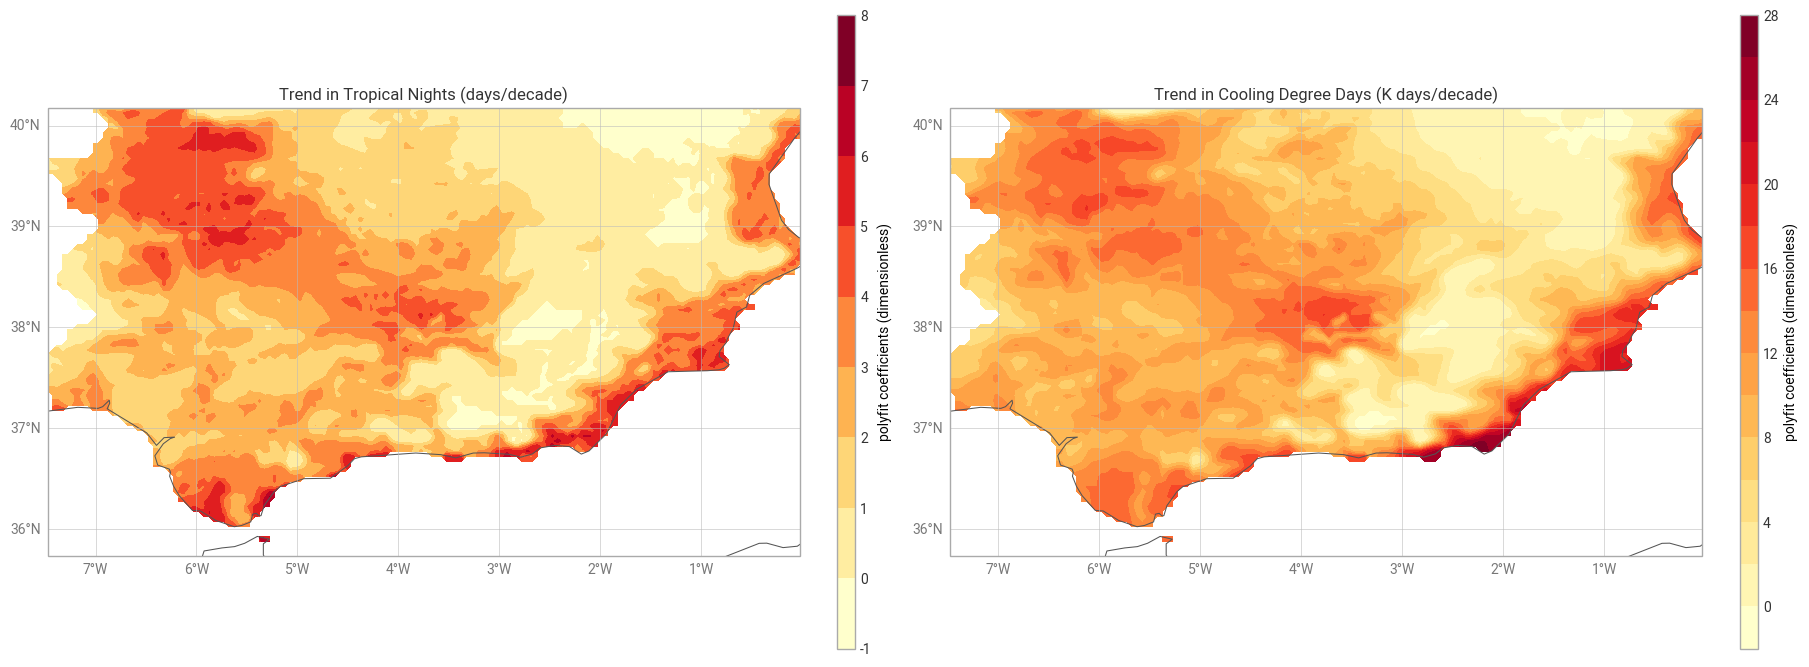

In [9]:
figure = ekp.Figure(rows=1, columns=2, size=(18, 8))

ax1 = figure.add_map(row=0, column=0)
ax1.quickplot(tn_trend, style=ekp.styles.Style(colors="YlOrRd"))
ax1.coastlines()
ax1.gridlines()
ax1.title("Trend in Tropical Nights (days/decade)")
ax1.legend(location="right")


ax2 = figure.add_map(row=0, column=1)
ax2.quickplot(cdd_trend, style=ekp.styles.Style(colors="YlOrRd"))
ax2.coastlines()
ax2.gridlines()
ax2.title("Trend in Cooling Degree Days (K days/decade)")

ax2.legend(location="right")


figure.show()

### Correlation Analysis

Finally, we analyze the relationship between tropical nights and cooling demand by plotting their correlation over time.

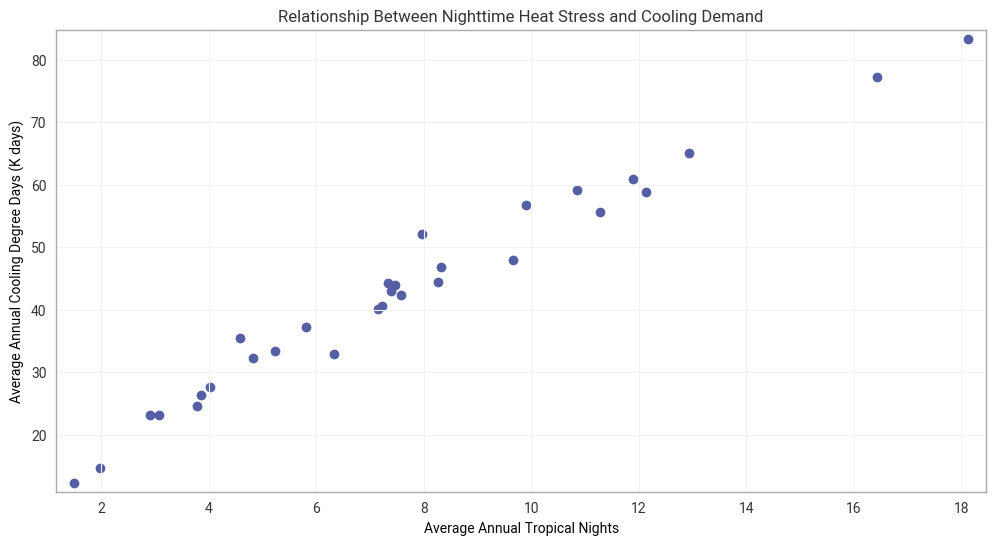

In [10]:
# Aggregating spatially for a simple correlation plot
tn_mean = tn.mean(dim=("lat", "lon"))
cdd_mean = cdd.mean(dim=("lat", "lon"))

plt.scatter(tn_mean, cdd_mean)
plt.xlabel("Average Annual Tropical Nights")
plt.ylabel("Average Annual Cooling Degree Days (K days)")
plt.title("Relationship Between Nighttime Heat Stress and Cooling Demand")
plt.grid(True)
plt.show()

The results confirm a sustained anthropogenic warming trend across the southern Iberian Peninsula, with an increase of up to 8 tropical nights per decade in coastal areas and the Guadalquivir Valley. The strong linear correlation observed in the scatter plot demonstrates that rising nighttime minimum temperatures are a critical driver of energy demand: as nights lose their capacity to naturally cool the environment, the Cooling Degree Days (CDD) index increases proportionally. This scenario suggests that, if current trends persist, the region will face not only public health challenges due to thermal stress but also growing pressure on electrical infrastructure and household economic sustainability due to a heightened reliance on air conditioning.